In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import kagglehub
from imblearn.over_sampling import SMOTE
from rich.jupyter import display

#Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")
kagglehub.login()

print("Path to dataset files:", path)

Path to dataset files: /Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [68]:
print("Arquivos no dataset:", os.listdir(path)) #verifica quais arquivos estão dentro da pasta

Arquivos no dataset: ['Teen_Mental_Health_Dataset.csv']


In [69]:
rota = os.path.join('/Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1', 'Teen_Mental_Health_Dataset.csv') #junta o caminho da pasta com o arquivo

In [70]:
df = pd.read_csv(rota)
df.shape #linhas + colunas

(1200, 13)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [72]:
df.head(8)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0


In [73]:
print("O número máximo de contagens 'null' no DataFrame é: ", df.isnull().sum().max())

O número máximo de contagens 'null' no DataFrame é:  0


In [74]:
ansiedade = 'anxiety_level'
print(df[ansiedade].value_counts())

anxiety_level
6     132
4     131
10    131
8     130
9     124
3     123
2     110
7     109
1     105
5     105
Name: count, dtype: int64


In [75]:
print(df['social_interaction_level'].unique())
print(df['platform_usage'].unique())
print(df['gender'].unique())

['low' 'high' 'medium']
['Instagram' 'TikTok' 'Both']
['male' 'female']


In [76]:
#remove espaços e converte tudo para minusculo
df['gender'] = df['gender'].str.lower().str.strip()
df['platform_usage'] = df['platform_usage'].str.lower().str.strip()
df['social_interaction_level'] = df['social_interaction_level'].str.lower().str.strip()

#Converter os objetos em Int
df['gender'] = df['gender'].map({'male': 1, 'female': 0})
df['platform_usage'] = df['platform_usage'].map({'instagram': 0, 'tiktok': 1, 'both': 2})
df['social_interaction_level'] = df['social_interaction_level'].map({'low': 0, 'medium': 1, 'high': 2})

## EDA (Exploratory Data Analysis)

<Axes: >

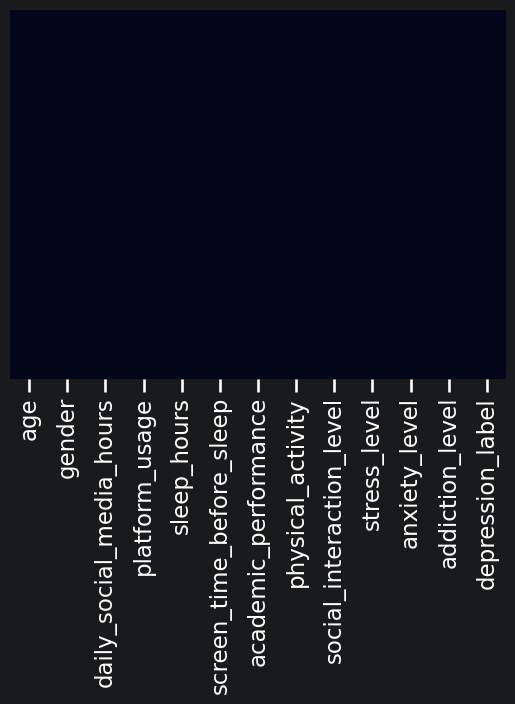

In [77]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [91]:
#como ansiedade tem muitas opções, delimitei um limite para cada valor, e depois colocando em categorias para facilitar a avaliação do modelo
limites = [0,3,7,10]
categorias = [0,1,2]

df['ansiedade'] = pd.cut(df[ansiedade], bins=limites, labels=categorias)
display(df[[ansiedade, 'ansiedade']].head(8))

,anxiety_level,ansiedade
0,2,0
1,1,0
2,4,1
3,7,1
4,5,1
5,5,1
6,2,0
7,10,2


In [92]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       1200 non-null   int64   
 1   gender                    1200 non-null   int64   
 2   daily_social_media_hours  1200 non-null   float64 
 3   platform_usage            1200 non-null   int64   
 4   sleep_hours               1200 non-null   float64 
 5   screen_time_before_sleep  1200 non-null   float64 
 6   academic_performance      1200 non-null   float64 
 7   physical_activity         1200 non-null   float64 
 8   social_interaction_level  1200 non-null   int64   
 9   stress_level              1200 non-null   int64   
 10  anxiety_level             1200 non-null   int64   
 11  addiction_level           1200 non-null   int64   
 12  depression_label          1200 non-null   int64   
 13  ansiedade                 1200 non-null   catego

In [93]:
X = df.drop('ansiedade', axis=1)
y = df['ansiedade']

# Separando Treino e Teste

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Tamanho do Treino: ', len(y_train))
print('Tamanho do Teste: ', len(y_test))
print('\nThe Test labels counts:')
print(y_test.value_counts())

Tamanho do Treino:  960
Tamanho do Teste:  240

The Test labels counts:
ansiedade
1    94
2    88
0    58
Name: count, dtype: int64


## Usando o SMOTE
Técnica avançada que ajuda a criar dados para o modelo aprender melhor.
De certa forma, ele inventa dados novos (sintéticos) que são matematicamente prováveis de existir

In [95]:
from imblearn.over_sampling import SMOTE

print('Tamanho do Treino antes: ', len(y_train))

smote = SMOTE(random_state=42, k_neighbors=5) #KNN -> vai funcionar com base na proximidade.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Tamanho do Treino antes: ', len(y_train_smote))

Tamanho do Treino antes:  960
Tamanho do Treino antes:  1149


### Treinando o Modelo

In [96]:
from sklearn.linear_model import LogisticRegression #irá fazer as contas matemáticas

regressor = LogisticRegression(max_iter=1000)

In [97]:
regressor.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Avaliação do Modelo

In [98]:
X.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [99]:
y_pred = regressor.predict(X_test)

In [100]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        94
           2       1.00      1.00      1.00        88

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

[[58  0  0]
 [ 0 94  0]
 [ 0  0 88]]
